# Street orientation entropy

Load the per-city bearing arrays written by `compute_orientations.py` and compute orientation-order statistics following Boeing (2019).

## Binning
Bearings (and reciprocals) are binned into $n = 36$ equal 10° bins, with edges shifted by −5° so that 0°, 90°, 180°, 270° sit at bin centers:
$$\text{edges} = \{-5°, 5°, 15°, \dots, 345°, 355°\}$$
Bearings in $[355°, 360°)$ wrap down into the first bin $[-5°, 5°)$.

## Unweighted entropy $H_o$ (Method 1 — simplified topology)
Endpoint-to-endpoint bearing of each simplified edge plus its reciprocal.
$$H_o = -\sum_{i=1}^{n} P(o_i)\,\ln P(o_i)$$
where $P(o_i)$ is the share of bearings in bin $i$.

## Weighted entropy $H_w$ (Method 2 — unsimplified topology)
Bearing of each raw straight-line OSM sub-segment plus its reciprocal, weighted by segment length:
$$H_w = -\sum_{i=1}^{n} P(o_i)\,\ln P(o_i)$$
with $P(o_i) = \sum_{k \in i} \ell_k \,/\, \sum_k \ell_k$.

## Reference values (natural log, $n = 36$ bins)
- $H_{\max} = \ln n = \ln 36 \approx 3.584$ nats (uniform distribution).
- $H_g = \ln 4 \approx 1.386$ nats (perfect 4-way grid).
- Undirected-graph minimum: $\ln 2 \approx 0.693$ nats (all streets along one axis).

## Orientation-order $\varphi$
Normalized to $[0, 1]$ with $\varphi = 0$ for uniform, $\varphi = 1$ for a perfect grid:
$$\varphi = 1 - \left(\frac{H - H_g}{H_{\max} - H_g}\right)^{2}$$

In [31]:
import os
import numpy as np
import pandas as pd

DATA_DIR = os.path.join('..', 'data', 'city_orientations')

# 36 bins of 10°, shifted by −5° so 0/90/180/270 sit at bin centers.
# Edges: [-5, 5, 15, ..., 345, 355]. Bearings in [355, 360) wrap into the first bin.
BIN_EDGES = np.arange(-5.0, 356.0, 10.0)
assert len(BIN_EDGES) == 37  # 36 bins

In [32]:
def orientation_entropy(bearings, weights=None):
    """Shannon entropy (nats) of a bearing distribution on 36 bins shifted by -5°."""
    b = np.asarray(bearings, dtype=float)
    b = b[np.isfinite(b)]
    # wrap [355, 360) into the first bin [-5, 5)
    b = np.where(b >= 355.0, b - 360.0, b)
    w = None if weights is None else np.asarray(weights, dtype=float)[np.isfinite(b)]
    counts, _ = np.histogram(b, bins=BIN_EDGES, weights=w)
    total = counts.sum()
    if total <= 0:
        return np.nan
    p = counts / total
    nz = p > 0
    return float(-(p[nz] * np.log(p[nz])).sum())

In [33]:
rows = []
for fname in sorted(os.listdir(DATA_DIR)):
    if not fname.endswith('.npz'):
        continue
    city = os.path.splitext(fname)[0]
    d = np.load(os.path.join(DATA_DIR, fname))
    H_o = orientation_entropy(d['method1_bearings'])
    rows.append({'city': city, 'n_edges': len(d['method1_bearings']) // 2, 'H_o': H_o})

df = pd.DataFrame(rows).sort_values('H_o').reset_index(drop=True)
df

,city,n_edges,H_o
0,"Vancouver,_Canada",146993,2.607569
1,"Luxembourg_City,_Luxembourg",309,2.967800
2,"Toronto,_Canada",368778,3.020325
3,"Perth,_Australia",4919,3.024063
4,"Santiago,_Chile",11453,3.049709
...,...,...,...
92,"Oslo,_Norway",176798,3.576363
93,"Hanoi,_Vietnam",392734,3.577444
94,"Riga,_Latvia",177771,3.577548
95,"Rome,_Italy",238449,3.578591


## Weighted entropy $H_w$

Now using Method 2 (unsimplified topology): each raw straight-line OSM segment contributes its bearing weighted by its length. Same 36 bins shifted by −5°, same Shannon formula:
$$H_w = -\sum_{i=1}^{36} P(o_i)\,\ln P(o_i)$$
where $P(o_i)$ is the length-weighted share of bearings in bin $i$.

In [37]:
rows = []
for fname in sorted(os.listdir(DATA_DIR)):
    if not fname.endswith('.npz'):
        continue
    city = os.path.splitext(fname)[0]
    d = np.load(os.path.join(DATA_DIR, fname))
    H_o = orientation_entropy(d['method1_bearings'])
    H_w = orientation_entropy(d['method2_bearings'], d['method2_weights'])
    rows.append({'city': city, 'H_o': H_o, 'H_w': H_w})

df = pd.DataFrame(rows).sort_values('H_w').reset_index(drop=True)
df

,city,H_o,H_w
0,"Vancouver,_Canada",2.607569,2.500012
1,"Luxembourg_City,_Luxembourg",2.967800,2.586814
2,"Santiago,_Chile",3.049709,2.856813
3,"Toronto,_Canada",3.020325,2.921610
4,"Perth,_Australia",3.024063,2.939097
...,...,...,...
92,"Palma_de_Mallorca,_Spain",3.573205,3.577298
93,"Hanoi,_Vietnam",3.577444,3.577599
94,"Hong_Kong,_China",3.576067,3.577998
95,"Rome,_Italy",3.578591,3.579277


## Orientation-order $\varphi$

Reference values on the 36-bin shifted scheme (natural log):
- $H_{\max} = \ln 36 \approx 3.584$ nats — uniform distribution across all 36 bins.
- $H_g = \ln 4 \approx 1.386$ nats — perfect 4-way grid (N/S/E/W in equal proportions).
- Undirected-graph minimum $\ln 2 \approx 0.693$ nats (all streets N–S, falling into 2 antipodal bins).

Normalized orientation-order, bounded in $[0, 1]$ with 0 = uniform and 1 = perfect grid:
$$\varphi = 1 - \left(\frac{H - H_g}{H_{\max} - H_g}\right)^{2}$$

In [38]:
H_MAX = np.log(36)  # ≈ 3.584
H_G   = np.log(4)   # ≈ 1.386

def phi(H):
    return 1.0 - ((H - H_G) / (H_MAX - H_G)) ** 2

df['phi_o'] = phi(df['H_o'])
df['phi_w'] = phi(df['H_w'])
df.sort_values('phi_w', ascending=False).reset_index(drop=True)

,city,H_o,H_w,phi_o,phi_w
0,"Vancouver,_Canada",2.607569,2.500012,0.691058,0.743078
1,"Luxembourg_City,_Luxembourg",2.967800,2.586814,0.481925,0.701469
2,"Santiago,_Chile",3.049709,2.856813,0.426871,0.552089
3,"Toronto,_Canada",3.020325,2.921610,0.446941,0.511745
4,"Perth,_Australia",3.024063,2.939097,0.444408,0.500560
...,...,...,...,...,...
92,"Palma_de_Mallorca,_Spain",3.573205,3.577298,0.009366,0.005655
93,"Hanoi,_Vietnam",3.577444,3.577599,0.005522,0.005381
94,"Hong_Kong,_China",3.576067,3.577998,0.006771,0.005019
95,"Rome,_Italy",3.578591,3.579277,0.004480,0.003857


## Polar histograms: top 4 and bottom 4 by $\varphi_w$ and $\varphi_o$

Each plot uses the same 36 shifted bins, with 0° at the top (north) and angles increasing clockwise. The 180° rotational symmetry comes from recording each bearing together with its reciprocal.

In [7]:
import matplotlib.pyplot as plt

def polar_hist(ax, bearings, weights=1, title=''):
    b = np.asarray(bearings, dtype=float)
    b = np.where(b >= 355.0, b - 360.0, b)
    w = None if weights is None else np.asarray(weights, dtype=float)
    counts, _ = np.histogram(b, bins=BIN_EDGES)
    freq = counts / counts.sum() if counts.sum() > 0 else counts
    centers_deg = np.arange(0.0, 360.0, 10.0)  # 0, 10, ..., 350
    theta = np.radians(centers_deg)
    width = np.radians(10.0)
    ax.bar(theta, freq, width=width, align='center',
           edgecolor='white', linewidth=0.5, color='#3b7dd8')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_yticklabels([])
    ax.set_xticks(np.radians([0, 90, 180, 270]))
    ax.set_xticklabels(['N', 'E', 'S', 'W'])
    ax.set_title(title, fontsize=10, pad=10)

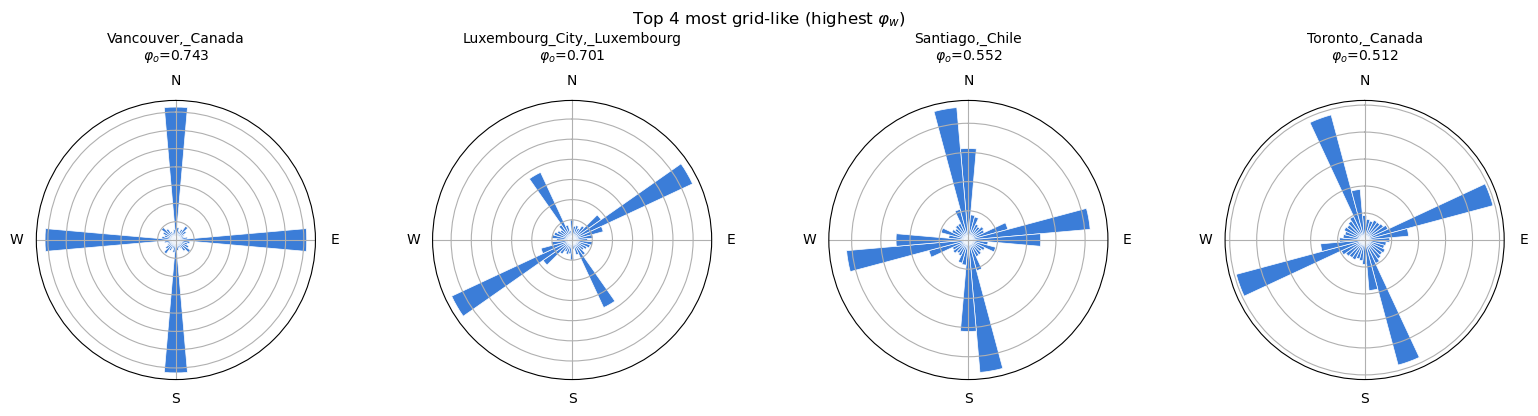

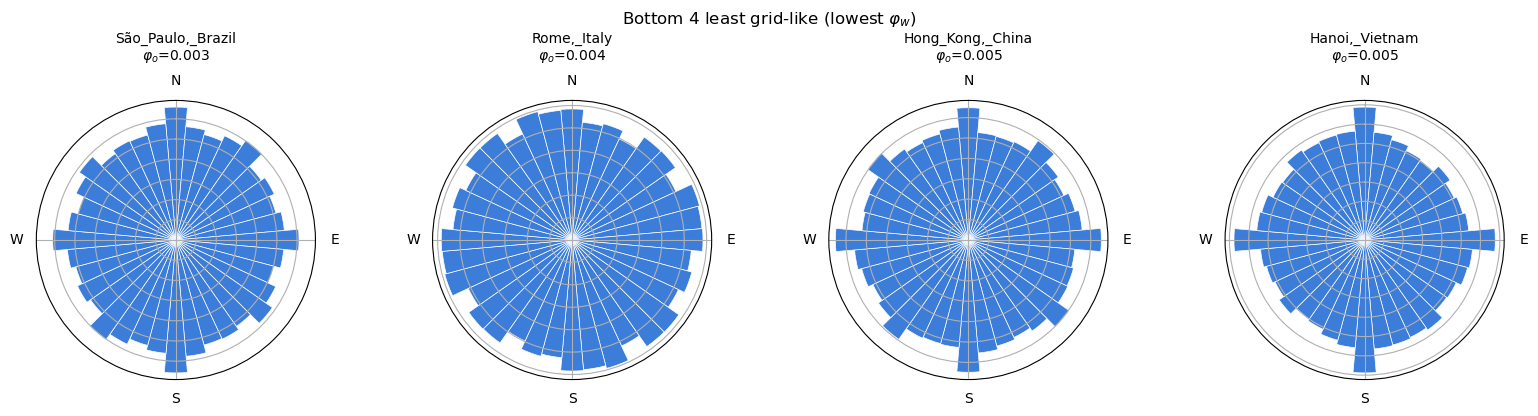

In [8]:
def plot_polar_grid(cities_df, suptitle):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), subplot_kw={'projection': 'polar'})
    for ax, (_, row) in zip(axes, cities_df.iterrows()):
        d = np.load(os.path.join(DATA_DIR, row['city'] + '.npz'))
        polar_hist(ax, d['method2_bearings'], d['method2_weights'],
                   title=f"{row['city']}\n$\\varphi_o$={row['phi_w']:.3f}")
    fig.suptitle(suptitle, fontsize=12)
    fig.tight_layout()
    return fig


ranked = df.sort_values('phi_w', ascending=False).reset_index(drop=True)
top4 = ranked.head(4)
bot4 = ranked.tail(4).iloc[::-1]  # highest-phi of the bottom first → most grid-like to least

plot_polar_grid(top4, 'Top 4 most grid-like (highest $\\varphi_w$)')
plot_polar_grid(bot4, 'Bottom 4 least grid-like (lowest $\\varphi_w$)')
plt.show()

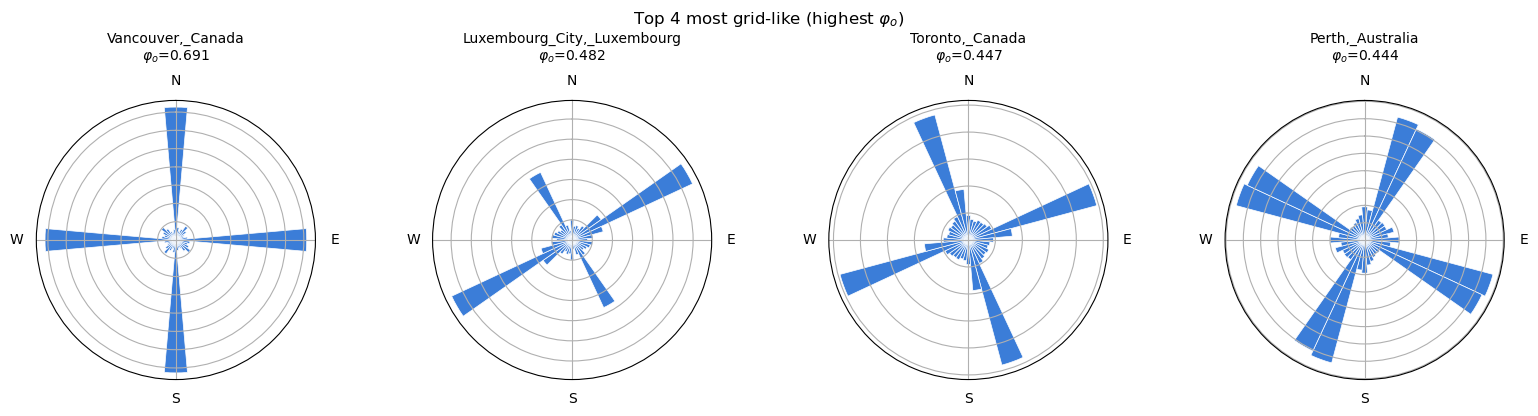

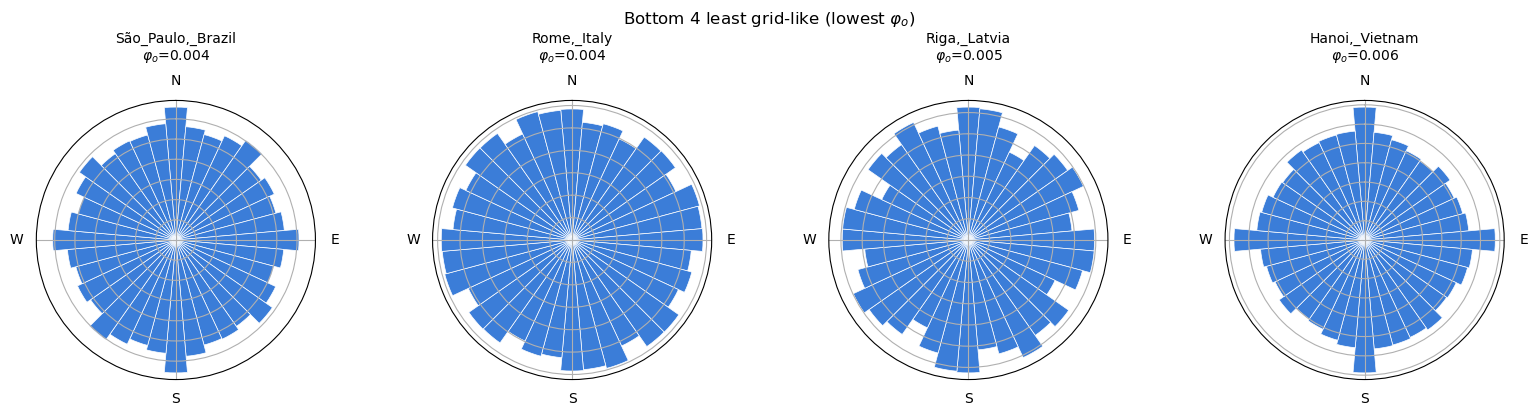

In [9]:
def plot_polar_grid(cities_df, suptitle):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), subplot_kw={'projection': 'polar'})
    for ax, (_, row) in zip(axes, cities_df.iterrows()):
        d = np.load(os.path.join(DATA_DIR, row['city'] + '.npz'))
        polar_hist(ax, d['method2_bearings'], d['method2_weights'],
                   title=f"{row['city']}\n$\\varphi_o$={row['phi_o']:.3f}")
    fig.suptitle(suptitle, fontsize=12)
    fig.tight_layout()
    return fig


ranked = df.sort_values('phi_o', ascending=False).reset_index(drop=True)
top4 = ranked.head(4)
bot4 = ranked.tail(4).iloc[::-1]  # highest-phi of the bottom first → most grid-like to least

plot_polar_grid(top4, 'Top 4 most grid-like (highest $\\varphi_o$)')
plot_polar_grid(bot4, 'Bottom 4 least grid-like (lowest $\\varphi_o$)')
plt.show()

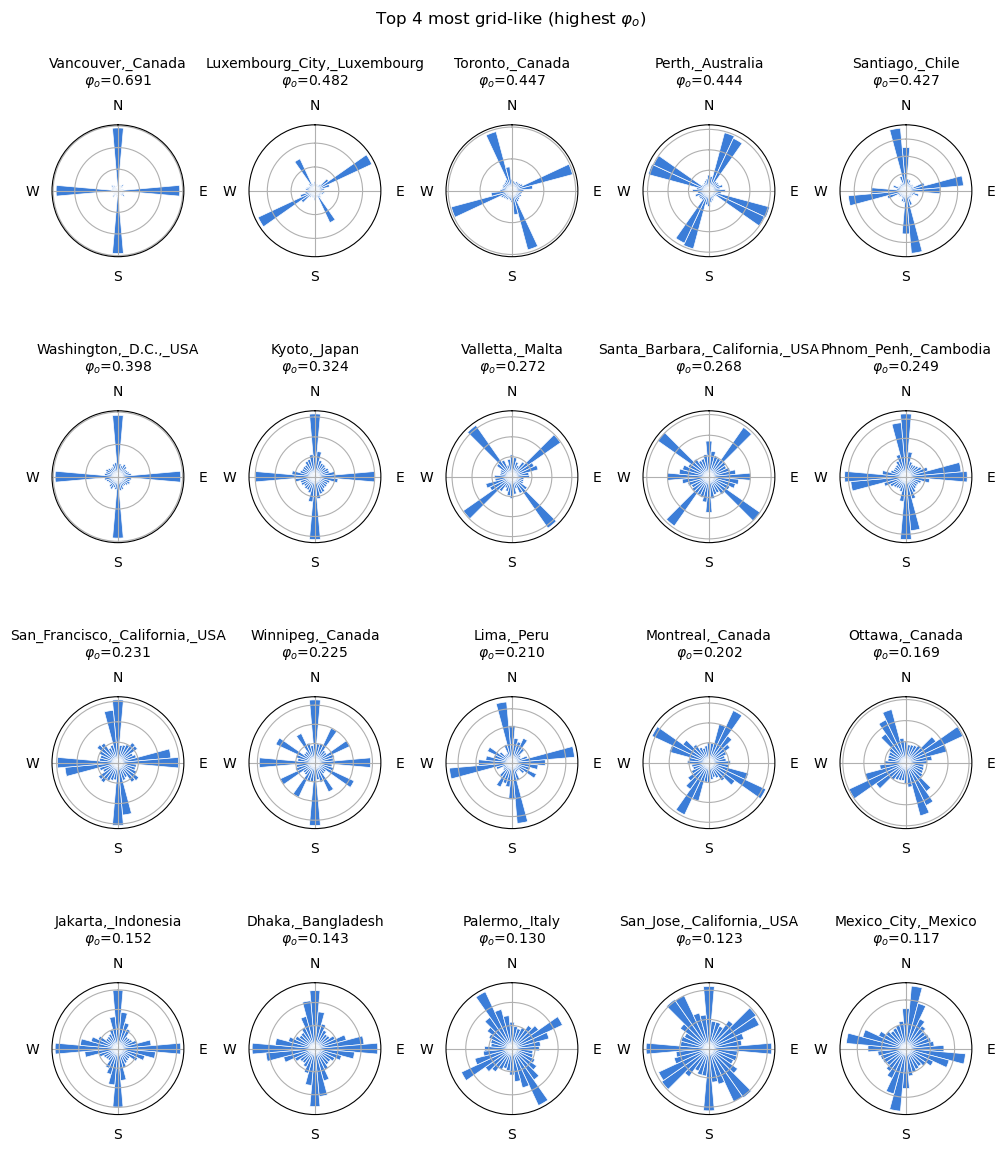

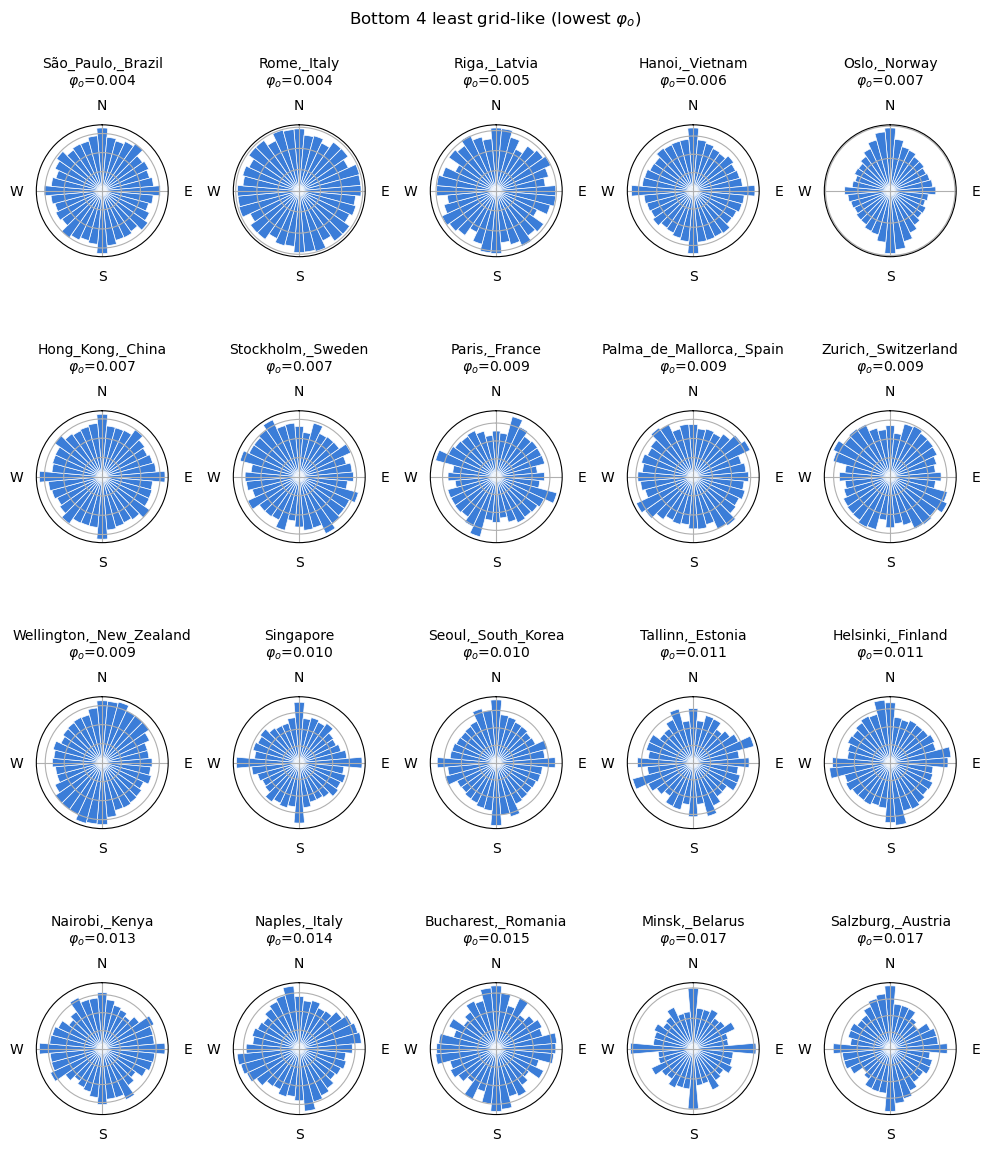

In [14]:
def plot_polar_grid(cities_df, suptitle):
    fig, axes = plt.subplots(4, 5, figsize=(10, 12), subplot_kw={'projection': 'polar'})
    axes = axes.ravel()
    
    for ax, (_, row) in zip(axes, cities_df.iterrows()):
        d = np.load(os.path.join(DATA_DIR, row['city'] + '.npz'))
        polar_hist(ax, d['method2_bearings'], d['method2_weights'],
            title=f"{row['city']}\n$\\varphi_o$={row['phi_o']:.3f}")
    
    fig.suptitle(suptitle, fontsize=12)
    fig.tight_layout()
    return fig


ranked = df.sort_values('phi_o', ascending=False).reset_index(drop=True)
top4 = ranked.head(20)
bot4 = ranked.tail(20).iloc[::-1]  # highest-phi of the bottom first → most grid-like to least

plot_polar_grid(top4, 'Top 4 most grid-like (highest $\\varphi_o$)')
plot_polar_grid(bot4, 'Bottom 4 least grid-like (lowest $\\varphi_o$)')
plt.show()

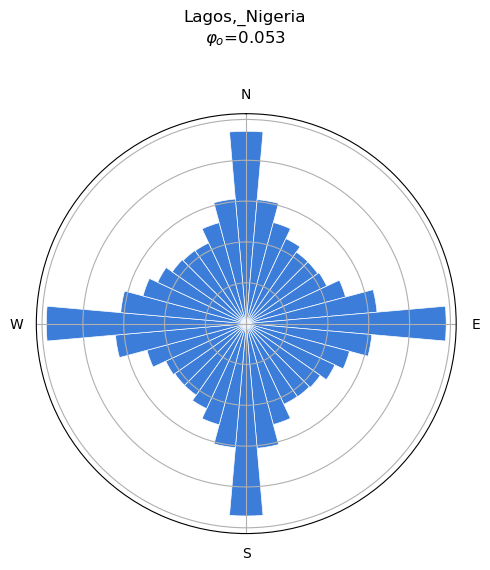

In [55]:
def pp(cities_df):
    fig, axes = plt.subplots(1, 1, figsize=(5, 6), subplot_kw={'projection': 'polar'})
    
    # Ensure axes is always iterable
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.ravel()
    
    for ax, (_, row) in zip(axes, cities_df.iterrows()):
        d = np.load(os.path.join(DATA_DIR, row['city'] + '.npz'))
        polar_hist(ax, d['method2_bearings'], d['method2_weights'])
    
    fig.suptitle(f"{row['city']}\n$\\varphi_o$={row['phi_o']:.3f}", fontsize=12)
    fig.tight_layout()
    return fig

ranked = df.sort_values('phi_o', ascending=False).reset_index(drop=True)
pp(df[df['city']=='Lagos,_Nigeria'])

plt.show()

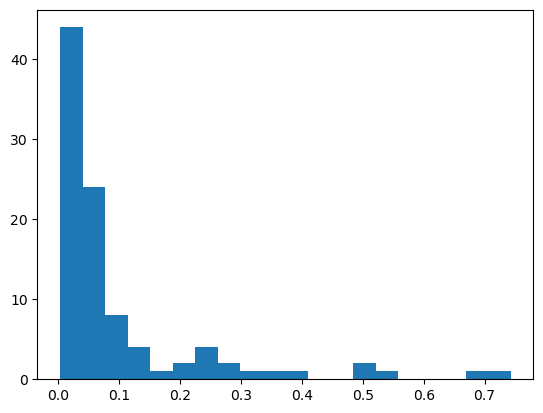

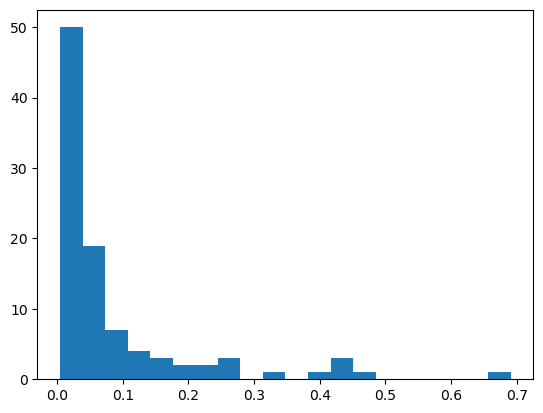

In [52]:
plt.hist(df['phi_w'],bins=20)
plt.show()

plt.hist(df['phi_o'],bins=20)
plt.show()

In [56]:
df

,city,H_o,H_w,phi_o,phi_w
0,"Vancouver,_Canada",2.607569,2.500012,0.691058,0.743078
1,"Luxembourg_City,_Luxembourg",2.967800,2.586814,0.481925,0.701469
2,"Santiago,_Chile",3.049709,2.856813,0.426871,0.552089
3,"Toronto,_Canada",3.020325,2.921610,0.446941,0.511745
4,"Perth,_Australia",3.024063,2.939097,0.444408,0.500560
...,...,...,...,...,...
92,"Palma_de_Mallorca,_Spain",3.573205,3.577298,0.009366,0.005655
93,"Hanoi,_Vietnam",3.577444,3.577599,0.005522,0.005381
94,"Hong_Kong,_China",3.576067,3.577998,0.006771,0.005019
95,"Rome,_Italy",3.578591,3.579277,0.004480,0.003857


In [65]:
import umap
from sklearn.cluster import KMeans

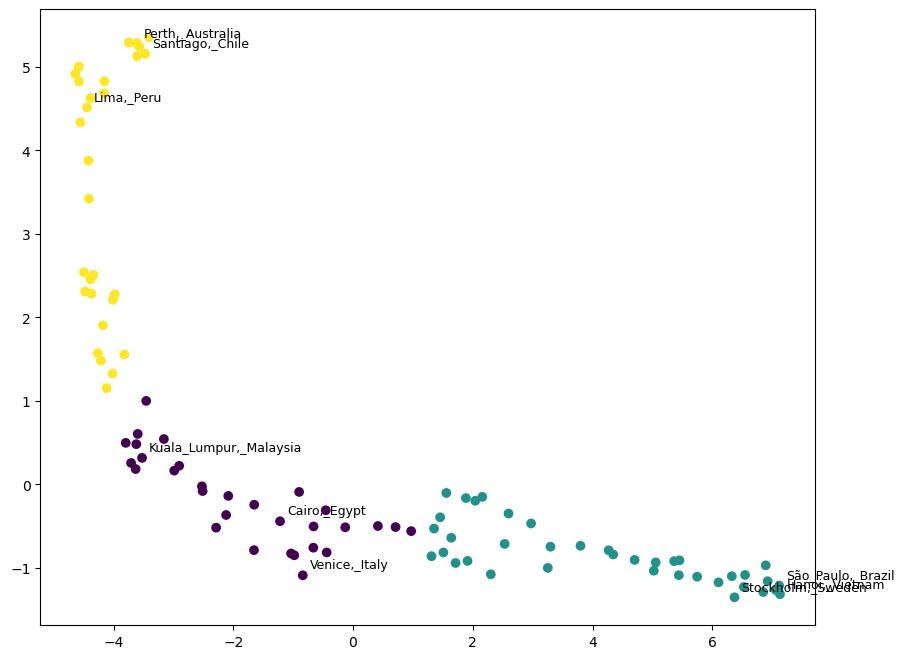

In [92]:
X = df[['H_o', 'H_w', 'phi_o', 'phi_w']]

umap_model = umap.UMAP(n_components=2)
X_embedded = umap_model.fit_transform(X)

# cluster
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_embedded)
labels = kmeans.labels_

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels, cmap='viridis')


for cluster_id in range(3):
    cluster_indices = np.where(labels == cluster_id)[0]
    chosen = np.random.choice(cluster_indices, size=min(3, len(cluster_indices)), replace=False)
    
    for idx in chosen:
        ax.annotate(df.iloc[idx]['city'],
                    (X_embedded[idx, 0], X_embedded[idx, 1]),
                    fontsize=9, xytext=(5, 5), textcoords='offset points')

plt.show()

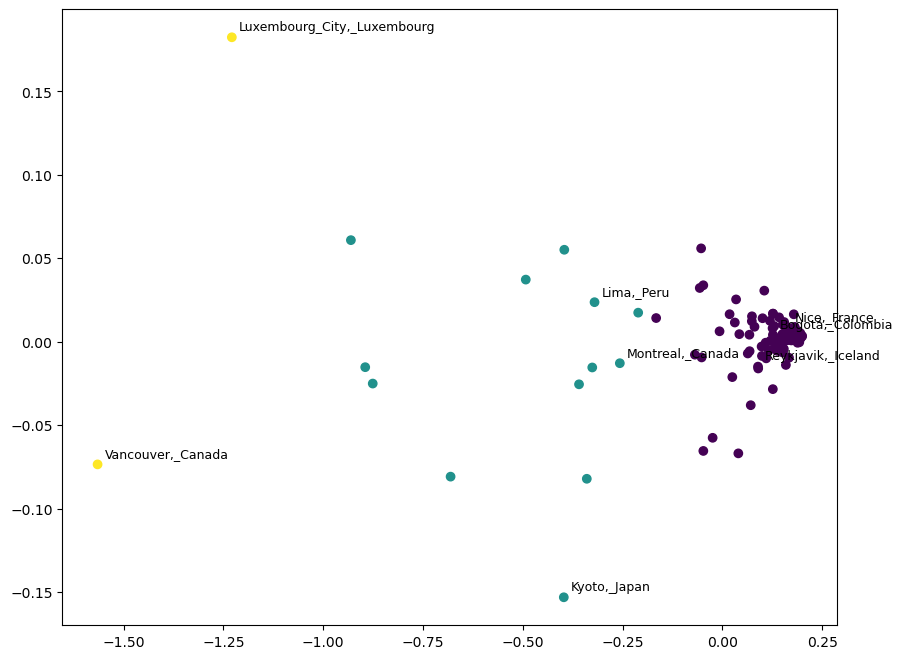

In [93]:
from sklearn.decomposition import PCA

X = df[['H_o', 'H_w', 'phi_o', 'phi_w']]

pca = PCA(n_components=2)
X_embedded = pca.fit_transform(X)

# cluster
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_embedded)
labels = kmeans.labels_

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels, cmap='viridis')


for cluster_id in range(3):
    cluster_indices = np.where(labels == cluster_id)[0]
    chosen = np.random.choice(cluster_indices, size=min(3, len(cluster_indices)), replace=False)
    
    for idx in chosen:
        ax.annotate(df.iloc[idx]['city'],
                    (X_embedded[idx, 0], X_embedded[idx, 1]),
                    fontsize=9, xytext=(5, 5), textcoords='offset points')

plt.show()

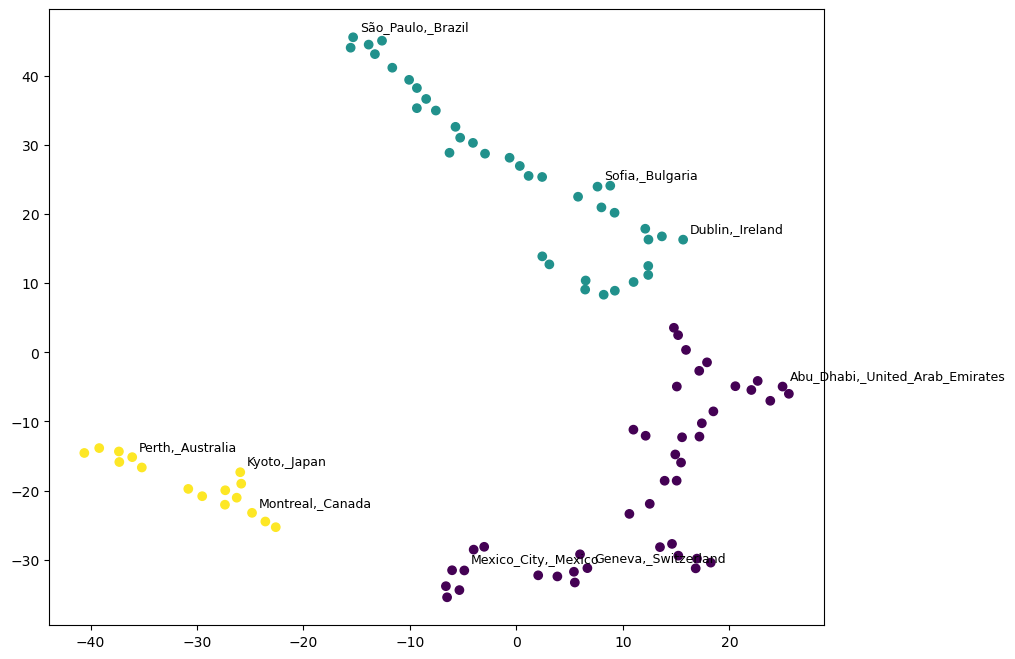

In [100]:
from sklearn.manifold import TSNE

X = df[['H_o', 'H_w', 'phi_o', 'phi_w']]

pca = TSNE(n_components=2,perplexity=5.0,)
X_embedded = pca.fit_transform(X)

# cluster
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_embedded)
labels = kmeans.labels_

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels, cmap='viridis')


for cluster_id in range(3):
    cluster_indices = np.where(labels == cluster_id)[0]
    chosen = np.random.choice(cluster_indices, size=min(3, len(cluster_indices)), replace=False)
    
    for idx in chosen:
        ax.annotate(df.iloc[idx]['city'],
                    (X_embedded[idx, 0], X_embedded[idx, 1]),
                    fontsize=9, xytext=(5, 5), textcoords='offset points')

plt.show()